In [1]:
import cv2
import numpy as np
import torch
from PIL import Image
import sys
sys.path.append("..")
from rich import print
from dataset import SCARED,HighlightDataset
from dataset.highlight import draw_rect
from utilities.visualization import rgb, panelize
%load_ext autoreload
%autoreload 2

In [2]:
dataset = HighlightDataset(
    SCARED(
        # There are 10 frames of SCARED in the dataset/sample_datasets/SCARED/ directory
        path="../dataset/sample_datasets/SCARED",
        vids=["v1"],
        frameskip=[1],
        height=512,
        width=640,
        with_depth=True,
    ),
    brightness_threshold=0.9,
    rect_size=(384, 384),
    return_mask=True,
    return_rect=True
)

dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)#, sampler=dataset.sampler)
iloader = iter(dataloader)
sample = next(iloader)
print({k:v.shape if isinstance(v,torch.Tensor) else v for k,v in sample.items()})

{
    'idx': torch.Size([1]),
    'framestack': torch.Size([1, 2, 3, 512, 640]),
    'Ts2t': torch.Size([1, 6]),
    'depthstack': torch.Size([1, 2, 1, 512, 640]),
    'paths': [
        ('../dataset/sample_datasets/SCARED/v1/poses_absolute/000013.json',),
        ('../dataset/sample_datasets/SCARED/v1/poses_absolute/000014.json',)
    ],
    'frameskip': torch.Size([1]),
    'intrinsics': torch.Size([1, 3, 3]),
    'Ts': torch.Size([1, 4, 4]),
    'Tt': torch.Size([1, 4, 4]),
    'highlight_masks': torch.Size([1, 2, 1, 512, 640]),
    'highlight_coverage': torch.Size([1, 2]),
    'rect_coords': torch.Size([1, 2, 4]),
    'rect_crop': torch.Size([1, 2, 3, 384, 384]),
    'rect_mask': torch.Size([1, 2, 1, 384, 384])
}

Percentage of highlighted pixels in output: 0.018762659281492233%

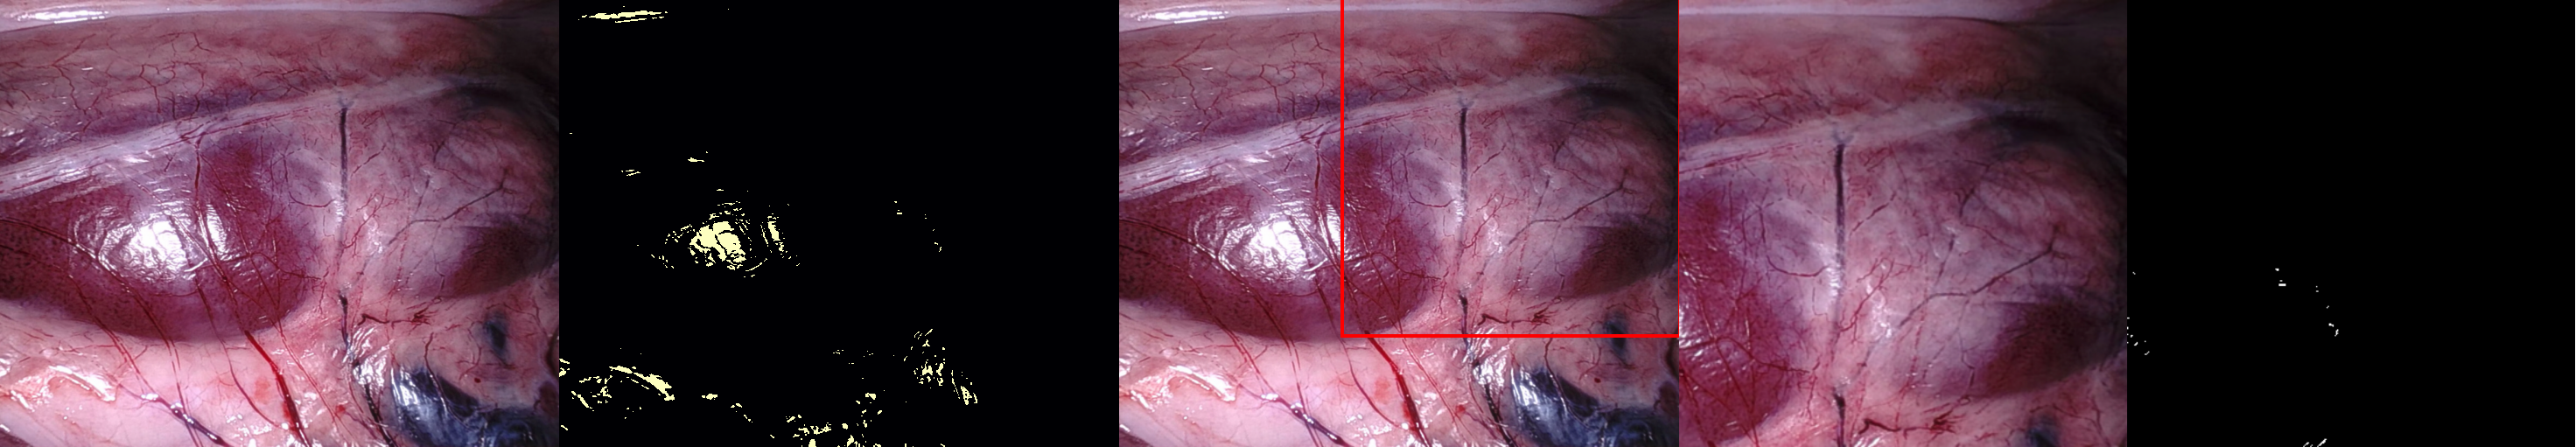

In [3]:
print(
    f"Percentage of highlighted pixels in output: {sample['rect_mask'][0].sum() / sample['rect_crop'][0].numel()*100}%"
)
rgb(
    panelize(
        rgb(
            sample["framestack"][0, 0],
            resize=(512, 640),
            as_tensor=True,
        ),
        rgb(
            sample["highlight_masks"][0, 0],
            resize=(512, 640),
            as_tensor=True,
        ),
        rgb(
            draw_rect(
                sample["framestack"][0, 0], (255, 0, 0), 4, sample["rect_coords"][0, 0]
            ),
            resize=(512, 640),
            as_tensor=True,
        ),
        rgb(sample["rect_crop"][0, 0], resize=(512, 512), as_tensor=True),
        rgb(
            sample["rect_mask"][0, 0],
            resize=(512, 512),
            as_tensor=True,
            colormap="gray",
        ),
        resize_to_match=False,
    )
)

In [4]:
import rerun as rr
import rerun.blueprint as rrb
rr.init("Reflection Generator")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.send_blueprint(
    rrb.Blueprint(
        rrb.Vertical(
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/source", name="Source RGB"),
                rrb.Spatial3DView(origin="/3d", name="3D Cloud"),
            ),
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/sourceref", name="Source and Reflections"),
                rrb.Spatial2DView(origin="/ref", name="Reflections Mask"),
            ),
        )
    )
)
rr.log("/3d", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)


In [5]:
import projections
from pipelines.depth.depth import DepthPipeline
from dotmap import DotMap
import yaml
## Load Configuration

# We load the configuration from the YAML file and convert it to a DotMap for easy access.
CONFIG_PATH = '../config.yaml'
with open(CONFIG_PATH, 'r') as f:
    config_yaml = yaml.safe_load(f)
    config_parameters = config_yaml['parameters']
    config_training_dict = {k: v.get('value') for k, v in config_parameters.items() if v is not None}
    config = DotMap(config_training_dict)
config.IMAGE_HEIGHT = 384
config.IMAGE_WIDTH = 384

highlighter = projections.HighLightRenderer(config.IMAGE_HEIGHT,config.IMAGE_WIDTH).cuda()
backproject = projections.BackProject(config.IMAGE_HEIGHT,config.IMAGE_WIDTH).cuda()
config.DEPTH_SCALE_FACTOR = 40
config.DEPTH_BIAS_FACTOR = 60

depthPipeline = DepthPipeline(config,model="", device="cuda")
cropdepth = depthPipeline.depth(sample["rect_crop"][:,0].cuda())
K = sample["intrinsics"][0].cuda()


LIGHT_INTENSITY = 100.0
LIGHT_COLOR = torch.tensor([1.0,1.0,1.0]).cuda()
SURFACE_SHININESS = 0.8
REFLECTION_STRENGTH = 0.5
n=17
moving_lightsource = 5*torch.randn(3).cuda()
moving_lightsource[2] = 0
xyz1, _, rgbvec = backproject(
    sample["rect_crop"][:,0].cuda(),
    cropdepth,
    torch.inverse(K).unsqueeze(0),
).values()
refres = highlighter(
    cloud=xyz1,
    rgb_vec=rgbvec,
    camera_K=K.unsqueeze(0),
    camera_T=torch.eye(4).unsqueeze(0).cuda(),
    light_position=moving_lightsource,  
    light_intensity=LIGHT_INTENSITY,  
    light_color=LIGHT_COLOR,  
    surface_roughness=SURFACE_SHININESS,  
    reflection_strength=REFLECTION_STRENGTH,  
)

rr.log(
    "/3d/cloud",
    rr.Points3D(
        positions=xyz1[0, :3].permute(1, 0).cpu().numpy(),
        colors=rgbvec[0].permute(1, 0).cpu().numpy(),
    ),
    static=True,
)
rr.log(
    "/3d/cam",
    rr.Pinhole(
        image_from_camera=K.cpu(),  # (3, 3)
        resolution=(384, 384),  # (2,)
        camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
    ),
    static=True,
)

rr.log(
    f"/ref",
    rr.Image(
        rgb(refres["reflection_only"][0], as_tensor=True)
        .permute(2, 1, 0)
        .cpu()
        .numpy()
    ),
)
rr.log(
    f"/source",
    rr.Image(rgb(sample["rect_crop"][0,0],resize=(config.IMAGE_HEIGHT,config.IMAGE_WIDTH),as_tensor=True).permute(2, 1, 0).cpu().numpy()),
)
rr.log(
    f"/sourceref",
    rr.Image(
        rgb(refres["warped"][0], as_tensor=True).permute(2, 1, 0).cpu().numpy()
    ),
)
rr.log(
    f"/3d/light",
    rr.Points3D(
        positions=moving_lightsource.cpu().numpy(),
        colors=LIGHT_COLOR.cpu().numpy(),
        radii=2,
    ),
)
# rgb(
#     panelize(
#         rgb(sample["rect_crop"][0,0],resize=(config.IMAGE_HEIGHT,config.IMAGE_WIDTH),as_tensor=True),
#         rgb(refres["warped"][0],resize=(config.IMAGE_HEIGHT,config.IMAGE_WIDTH),as_tensor=True),
#         rgb(refres["reflection_only"][0],resize=(config.IMAGE_HEIGHT,config.IMAGE_WIDTH),as_tensor=True,colormap="gray"),
#     )
# )

In [9]:
import rerun as rr
import rerun.blueprint as rrb
rr.init("FeatureTSDF")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.send_blueprint(
    rrb.Blueprint(
        rrb.Vertical(
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/source", name="Source RGB"),
                rrb.Spatial3DView(origin="/3d", name="3D Cloud"),
            ),
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/sourceref", name="Source and Reflections"),
                rrb.Spatial2DView(origin="/ref", name="Reflections Mask"),
            ),
        )
    )
)
rr.log("/3d", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)


In [10]:

rr.log(
    "/3d/cloud",
    rr.Points3D(
        positions=xyz1[0, :3].permute(1, 0).cpu().numpy(),
        colors=rgbvec[0].permute(1, 0).cpu().numpy(),
    ),
    static=True,
)
rr.log(
    "/3d/cam",
    rr.Pinhole(
        image_from_camera=K.cpu(),  # (3, 3)
        resolution=(384, 384),  # (2,)
        camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
    ),
    static=True,
)

rr.log(
    f"/ref",
    rr.Image(
        rgb(refres["reflection_only"][0], as_tensor=True)
        .permute(2, 1, 0)
        .cpu()
        .numpy()
    ),
)
rr.log(
    f"/source",
    rr.Image(rgb(sample["rect_crop"][0,0],resize=(config.IMAGE_HEIGHT,config.IMAGE_WIDTH),as_tensor=True).permute(2, 1, 0).cpu().numpy()),
)
rr.log(
    f"/sourceref",
    rr.Image(
        rgb(refres["warped"][0], as_tensor=True).permute(2, 1, 0).cpu().numpy()
    ),
)
rr.log(
    f"/3d/light",
    rr.Points3D(
        positions=moving_lightsource.cpu().numpy(),
        colors=LIGHT_COLOR.cpu().numpy(),
        radii=2,
    ),
)